In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [2]:
df = pd.read_csv('cleaned_resumeJD_pairs.csv')
print(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Columns: {df.columns.to_list()}")
print(f"\nLabel distribution:")
print(df['label'].value_counts())
df.head(3)

Loaded: 6234 rows, 7 columns
Columns: ['resume_text', 'job_description_text', 'label', 'match_score', 'match_label_lower', 'resume_len', 'jd_len']

Label distribution:
label
no fit           3142
potential fit    1554
good fit         1538
Name: count, dtype: int64


,resume_text,job_description_text,label,match_score,match_label_lower,resume_len,jd_len
0,SummaryHighly motivated Sales Associate with e...,Net2Source Inc. is an award-winning total work...,no fit,0.7132,no fit,794,559
1,Professional SummaryCurrently working with Cat...,At Salas OBrien we tell our clients that were ...,no fit,0.6445,no fit,863,568
2,SummaryI started my construction career in Jun...,Schweitzer Engineering Laboratories (SEL) Infr...,no fit,0.7522,no fit,872,438


In [4]:
print("Loading the BERT Model...")

model = SentenceTransformer('all-mpnet-base-v2')

print("Model Loaded!!")
print(f" Model:       all-mpnet-base-v2")
print(f" Parameters:  22.7M")
print(f"Embed dims:   768")
print(f"Max Tokens:   {model.max_seq_length}")

Loading the BERT Model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model Loaded!!
 Model:       all-mpnet-base-v2
 Parameters:  22.7M
Embed dims:   768
Max Tokens:   384


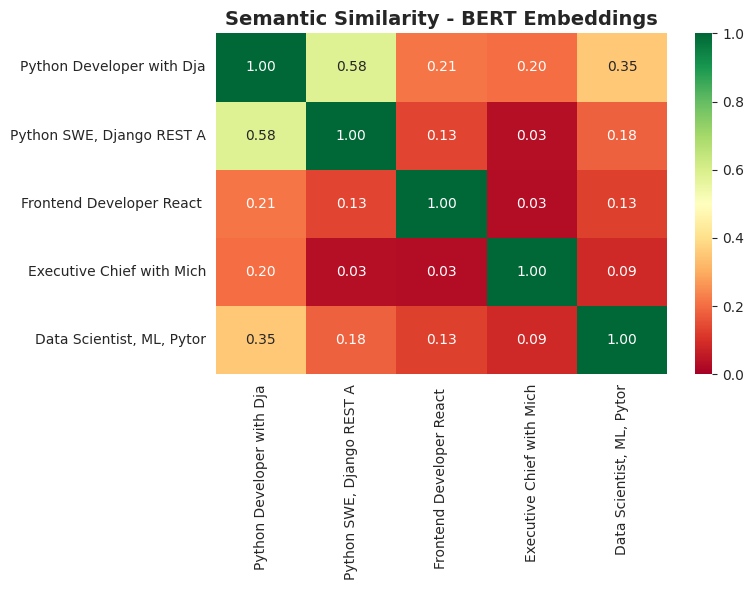

In [5]:
# BERT Embeddings

texts = [
    "Python Developer with Django Experience",
    "Python SWE, Django REST APIS",
    "Frontend Developer React and JS",
    "Executive Chief with Michelin Experience",
    "Data Scientist, ML, Pytorch",
]

embeddings = model.encode(texts)
sim_matrix = cosine_similarity(embeddings)

plt.figure(figsize=(8, 6))
sns.heatmap(sim_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            xticklabels=[t[:25] for t in texts],
            yticklabels=[t[:25] for t in texts],
            vmin=0, vmax=1)
plt.title('Semantic Similarity - BERT Embeddings', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
print("Generating resume embeddings...")
resume_embeddings = model.encode(
    df['resume_text'].tolist(),
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("\nGenerating job description embeddings...")
jd_embeddings = model.encode(
    df['job_description_text'].tolist(),
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

print(f"\nResume embeddings shape: {resume_embeddings.shape}")
print(f"Job description embeddings shape: {jd_embeddings.shape}")
print(f"Each text -> {resume_embeddings.shape[1]}-dimensional vector")

Generating resume embeddings...


Batches:   0%|          | 0/195 [00:00<?, ?it/s]


Generating job description embeddings...


Batches:   0%|          | 0/195 [00:00<?, ?it/s]


Resume embeddings shape: (6234, 768)
Job description embeddings shape: (6234, 768)
Each text -> 768-dimensional vector


In [8]:
pair_similarities = []
for i in range(len(resume_embeddings)):
  sim = cosine_similarity([resume_embeddings[i]], [jd_embeddings[i]])[0][0]
  pair_similarities.append(sim)

df['bert_similarity'] = pair_similarities

print("Cosine similarity computed for all pairs.")
print(df[['label', 'match_score', 'bert_similarity']].head(10))

Cosine similarity computed for all pairs.
    label  match_score  bert_similarity
0  no fit       0.7132         0.544038
1  no fit       0.6445         0.478275
2  no fit       0.7522         0.497848
3  no fit       0.6135         0.277842
4  no fit       0.6612         0.385589
5  no fit       0.6693         0.473125
6  no fit       0.6912         0.506966
7  no fit       0.6757         0.497814
8  no fit       0.6717         0.410320
9  no fit       0.6718         0.427328


In [9]:
# Base model performance: How GOOD is BERT out of Box?

mae = mean_absolute_error(df['match_score'], df['bert_similarity'])
rmse = np.sqrt(mean_squared_error(df['match_score'], df['bert_similarity']))

print("Base BERT Model Performance (before fine-tuning):")
print("=" * 50)
print(f"MAE: {mae:.4f} (lower is better)")
print(f"RMSE: {rmse:.4f} (lower is better)")

Base BERT Model Performance (before fine-tuning):
MAE: 0.1917 (lower is better)
RMSE: 0.2135 (lower is better)


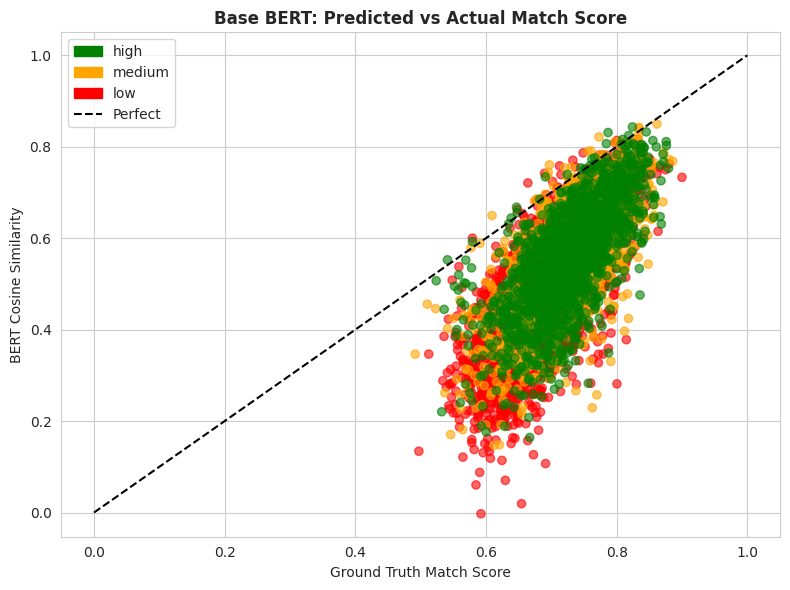

In [12]:
# Scatter: predicted vs ground truth
plt.figure(figsize=(8, 6))
colors = df['label'].map({'no fit':'red', 'potential fit': 'orange', 'good fit': 'green'})
plt.scatter(df['match_score'], df['bert_similarity'], c=colors, alpha=0.6)
plt.plot([0, 1], [0, 1], 'k--', label='Perfect Prediction')
plt.xlabel('Ground Truth Match Score')
plt.ylabel('BERT Cosine Similarity')
plt.title('Base BERT: Predicted vs Actual Match Score', fontweight='bold')

from matplotlib.patches import Patch
plt.legend(handles=[
    Patch(color='green', label='high'),
    Patch(color='orange', label='medium'),
    Patch(color='red', label='low'),
    plt.Line2D([0],[0], color='black', linestyle='--', label='Perfect')
])
plt.tight_layout()
plt.show()

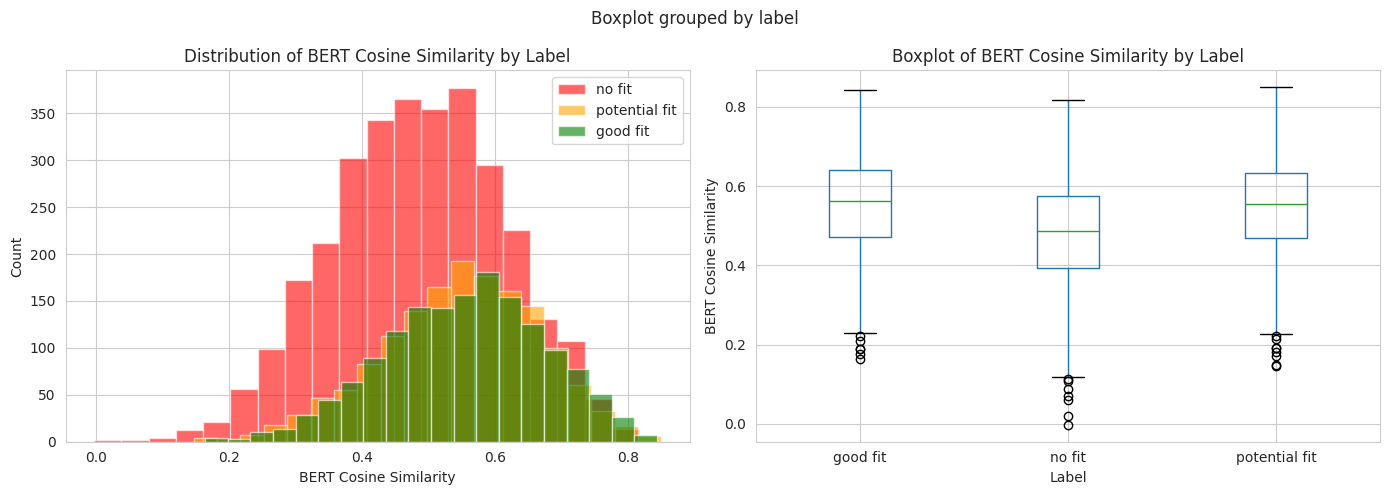

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, color in [('no fit', 'red'), ('potential fit', 'orange'), ('good fit', 'green')]:
    subset = df[df['label'] == label]['bert_similarity']
    axes[0].hist(subset, bins=20, alpha=0.6, label=label, color=color)

axes[0].set_xlabel('BERT Cosine Similarity')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of BERT Cosine Similarity by Label')
axes[0].legend()

# Box Plot
df.boxplot(column='bert_similarity', by='label',
           positions=[0,1,2], ax=axes[1])
axes[1].set_xlabel('Label')
axes[1].set_ylabel('BERT Cosine Similarity')
axes[1].set_title('Boxplot of BERT Cosine Similarity by Label')

plt.tight_layout()
plt.show()

In [14]:
import pickle

with open('resume_embeddings.pkl', 'wb') as f:
    pickle.dump({
        'resume_embeddings': resume_embeddings,
        'jd_embeddings':     jd_embeddings,
        'match_scores':      df['match_score'].tolist(),
        'labels':            df['label'].tolist()
    }, f)

print("Saved: resume_embeddings.pkl")
print(f"  resume_embeddings: {resume_embeddings.shape}")
print(f"  jd_embeddings:     {jd_embeddings.shape}")
print()
print("These will be loaded for fine-tuning.")

Saved: resume_embeddings.pkl
  resume_embeddings: (6234, 768)
  jd_embeddings:     (6234, 768)

These will be loaded for fine-tuning.
